# Adult Income: data audit and benchmark-ready preprocessing

**Goal:** build a trustworthy data foundation for a later classical-model and neural-network benchmark.

This notebook answers four practical questions:

1. What is actually in the local file?
2. Which data issues matter for this prediction task?
3. Which transformations are justified by measured behavior?
4. How should the data be split and passed to models without leakage?

**Scope boundary:** this notebook stops before model training. Model comparison, tuning, threshold selection, final test evaluation, and error analysis belong in the next benchmark notebook. Keeping that boundary makes the test set genuinely useful.

## 1. Problem, provenance, and limits

The [UCI Adult dataset card](https://doi.org/10.24432/C5XW20) describes a binary task: predict whether annual income exceeds $50,000. UCI says the data were extracted from a **1994 Census database**, contain missing values, and include 14 predictors.

The official [adult.names](https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.names) file adds important context:

- adult.data has 32,561 rows and adult.test has 16,281 rows.
- The official files were created with a random 2/3–1/3 split.
- Unknown values were written as a question mark.
- fnlwgt is a Current Population Survey final population weight.

Only adult.data exists locally. Therefore, this notebook creates an internal holdout. Results from that holdout will **not** be directly comparable with papers using the official adult.test file.

> **Senior habit:** define the population, prediction time, target, and evaluation unit before choosing a model. Here, no timestamp, person ID, household ID, deployment context, or error costs are available. Honest claims must stay within those limits.

In [1]:
import hashlib
import platform
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
from IPython.display import display
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler

RANDOM_STATE = 42
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 20)

versions = pd.Series({
    "Python": platform.python_version(),
    "pandas": pd.__version__,
    "NumPy": np.__version__,
    "scikit-learn": sklearn.__version__,
})
versions.to_frame("version")

,version
Python,3.12.0
pandas,3.0.3
NumPy,2.4.6
scikit-learn,1.8.0


## 2. Load the raw file correctly

The file has no header. Its fields have a space after each comma, and the question mark is the documented missing marker. The loader handles these facts directly instead of repairing strings later.

The SHA-256 hash pins this analysis to the exact supplied file. A changed file should fail loudly and be reviewed as a new data version.

In [2]:
DATA_PATH = Path("census+income/adult.data")
if not DATA_PATH.exists():
    DATA_PATH = Path("ML_benchmark/Classification/census+income/adult.data")

COLUMNS = [
    "age", "workclass", "fnlwgt", "education", "education_num",
    "marital_status", "occupation", "relationship", "race", "sex",
    "capital_gain", "capital_loss", "hours_per_week",
    "native_country", "income",
]

EXPECTED_SHA256 = "5b00264637dbfec36bdeaab5676b0b309ff9eb788d63554ca0a249491c86603d"
file_hash = hashlib.sha256(DATA_PATH.read_bytes()).hexdigest()

raw = pd.read_csv(
    DATA_PATH,
    header=None,
    names=COLUMNS,
    skipinitialspace=True,
    na_values="?",
    keep_default_na=False,
)

raw["income"] = raw["income"].str.strip().str.rstrip(".")
raw.index = raw.index + 1
raw.index.name = "source_row"

pd.Series({
    "path": DATA_PATH.as_posix(),
    "rows": len(raw),
    "columns": raw.shape[1],
    "sha256": file_hash,
}).to_frame("value")

,value
path,census+income/adult.data
rows,32561
columns,15
sha256,5b00264637dbfec36bdeaab5676b0b309ff9eb788d6355...


In [3]:
schema = pd.DataFrame({
    "dtype": raw.dtypes.astype(str),
    "missing": raw.isna().sum(),
    "unique_including_missing": raw.nunique(dropna=False),
})

display(raw.head(3))
display(schema)

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
source_row,,,,,,,,,,,,,,,
1,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
2,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
3,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K


,dtype,missing,unique_including_missing
age,int64,0,73
workclass,str,1836,9
fnlwgt,int64,0,21648
education,str,0,16
education_num,int64,0,16
marital_status,str,0,7
occupation,str,1843,15
relationship,str,0,6
race,str,0,5
sex,str,0,2


In [4]:
allowed_missing = {"workclass", "occupation", "native_country"}
actual_missing = set(raw.columns[raw.isna().any()])

assert DATA_PATH.exists()
assert file_hash == EXPECTED_SHA256
assert raw.shape == (32_561, 15)
assert set(raw["income"]) == {"<=50K", ">50K"}
assert actual_missing == allowed_missing
assert raw["age"].gt(16).all()
assert raw["hours_per_week"].gt(0).all()
assert raw["fnlwgt"].gt(1).all()
assert raw[["capital_gain", "capital_loss"]].ge(0).all().all()

pd.Series({
    "file version matches": True,
    "shape matches": True,
    "target domain matches": True,
    "missing columns match": True,
    "documented extraction minima pass": True,
}).to_frame("contract_check")

,contract_check
file version matches,True
shape matches,True
target domain matches,True
missing columns match,True
documented extraction minima pass,True


> **Senior habit:** separate a data contract from exploratory analysis. Contracts catch silent schema changes; plots do not.

## 3. Structural quality audit

First inspect missingness, exact repetition, contradictory labels, cardinality, and value ranges. Do not delete or impute anything before understanding what it means.

In [5]:
feature_columns = COLUMNS[:-1]
label_counts_per_profile = raw.groupby(
    feature_columns,
    dropna=False,
)["income"].nunique()

quality_summary = pd.Series({
    "rows": len(raw),
    "rows with any missing value": raw.isna().any(axis=1).sum(),
    "exact duplicate rows beyond first": raw.duplicated().sum(),
    "duplicate feature rows beyond first": raw.duplicated(
        subset=feature_columns
    ).sum(),
    "feature profiles with conflicting labels": (
        label_counts_per_profile > 1
    ).sum(),
})
quality_summary.to_frame("count")

,count
rows,32561
rows with any missing value,2399
exact duplicate rows beyond first,24
duplicate feature rows beyond first,25
feature profiles with conflicting labels,1


In [6]:
missing_summary = pd.DataFrame({
    "missing_rows": raw.isna().sum(),
    "missing_rate_pct": raw.isna().mean().mul(100).round(2),
})
missing_summary = missing_summary.query("missing_rows > 0")

missing_columns = missing_summary.index.tolist()
missing_patterns = (
    raw[missing_columns]
    .isna()
    .value_counts()
    .rename("rows")
    .reset_index()
)

display(missing_summary)
display(missing_patterns)

,missing_rows,missing_rate_pct
workclass,1836,5.64
occupation,1843,5.66
native_country,583,1.79


,workclass,occupation,native_country,rows
0,False,False,False,30162
1,True,True,False,1809
2,False,False,True,556
3,True,True,True,27
4,False,True,False,7


**Measured findings**

- 2,399 rows (7.37%) contain at least one missing value. Dropping them would discard a meaningful part of the sample.
- Workclass and occupation are usually missing together. Filling both with their most common values could invent a false employment combination.
- There are 24 exact repeated rows and one identical 14-feature profile with conflicting labels. The file has no person ID, so identical rows cannot honestly be declared repeated people.

**Decision:** keep the records, but force identical full predictor profiles into the same data partition. This prevents literal copies from crossing train/test or CV boundaries without pretending to know their identity.

## 4. Lock the test set before target-guided EDA

A five-fold StratifiedGroupKFold provides an approximately 80/20 holdout. Stratification preserves the class ratio; grouping keeps identical 14-feature raw profiles together.

This estimates same-source random-row generalization with an exact-profile constraint. It does **not** test future-time, new-household, or current-population generalization because the required identifiers and timestamps do not exist.

Grouping applies to all 14 published predictors. After the primary policy removes education and fnlwgt, distinct survey rows can still share the same final model vector. That is expected under row-level evaluation and is not evidence that they are the same person.

In [7]:
raw["target"] = raw["income"].map({"<=50K": 0, ">50K": 1}).astype("int8")
profile_group = pd.util.hash_pandas_object(
    raw[feature_columns],
    index=False,
)

holdout_split = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)
development_position, test_position = next(
    holdout_split.split(raw, raw["target"], profile_group)
)

development = raw.iloc[development_position].copy()
locked_test = raw.iloc[test_position].copy()
development_group = profile_group.iloc[development_position].to_numpy()
test_group = profile_group.iloc[test_position].to_numpy()

assert set(development.index).isdisjoint(locked_test.index)
assert set(development_group).isdisjoint(test_group)
assert len(development) + len(locked_test) == len(raw)

split_summary = pd.DataFrame({
    "rows": [len(development), len(locked_test)],
    "share_pct": [
        100 * len(development) / len(raw),
        100 * len(locked_test) / len(raw),
    ],
}, index=["development", "locked_test"]).round(2)

split_summary

,rows,share_pct
development,26049,80.0
locked_test,6512,20.0


The complete file was used only for the pre-split schema and integrity audit. From this point, target-guided EDA and feature decisions use only the development partition. No preprocessing or model is fitted on the locked test, which is reserved for one final score after model and threshold decisions.

[Scikit-learn's common-pitfalls guide](https://scikit-learn.org/stable/common_pitfalls.html) explicitly recommends splitting before learned preprocessing and fitting transformations only on training data.

## 5. Target behavior


,rows,rate_pct
<=50K,19776,75.92
>50K,6273,24.08


Majority-class accuracy baseline: 0.759


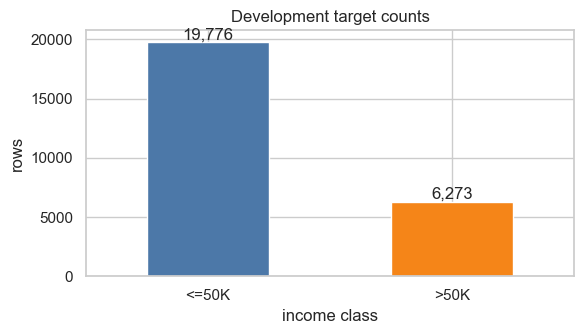

In [8]:
target_summary = development["target"].value_counts().sort_index().to_frame("rows")
target_summary["rate_pct"] = (
    development["target"].value_counts(normalize=True).sort_index().mul(100)
)
target_summary.index = ["<=50K", ">50K"]

majority_accuracy = development["target"].value_counts(normalize=True).max()
display(target_summary.round(2))
print(f"Majority-class accuracy baseline: {majority_accuracy:.3f}")

ax = target_summary["rows"].plot.bar(
    color=["#4C78A8", "#F58518"],
    figsize=(6, 3.5),
    rot=0,
    title="Development target counts",
)
ax.set(xlabel="income class", ylabel="rows")
ax.bar_label(ax.containers[0], fmt="{:,.0f}")
plt.tight_layout()
plt.show()

The positive class is about 24%, so imbalance is **moderate**, not extreme. A useless always-negative model is already about 76% accurate. The later benchmark must include a dummy baseline and must not select a winner by raw accuracy alone.

## 6. Numeric behavior

Start with ranges and distributions. Do not call a value an outlier merely because it is large; first ask whether it is impossible, erroneous, top-coded, or simply rare.

In [9]:
numeric_audit = [
    "age", "fnlwgt", "education_num", "capital_gain",
    "capital_loss", "hours_per_week",
]

development[numeric_audit].describe(
    percentiles=[0.01, 0.25, 0.50, 0.75, 0.99]
).T.round(2)

,count,mean,std,min,1%,25%,50%,75%,99%,max
age,26049.0,38.59,13.61,17.0,17.00,28.0,37.0,48.0,74.0,90.0
fnlwgt,26049.0,189641.26,105629.73,12285.0,27174.64,117833.0,178353.0,236627.0,511346.6,1484705.0
education_num,26049.0,10.07,2.57,1.0,3.00,9.0,10.0,12.0,16.0,16.0
capital_gain,26049.0,1066.22,7306.98,0.0,0.00,0.0,0.0,0.0,15024.0,99999.0
capital_loss,26049.0,86.03,400.63,0.0,0.00,0.0,0.0,0.0,1980.0,4356.0
hours_per_week,26049.0,40.44,12.38,1.0,8.00,40.0,40.0,45.0,80.0,99.0


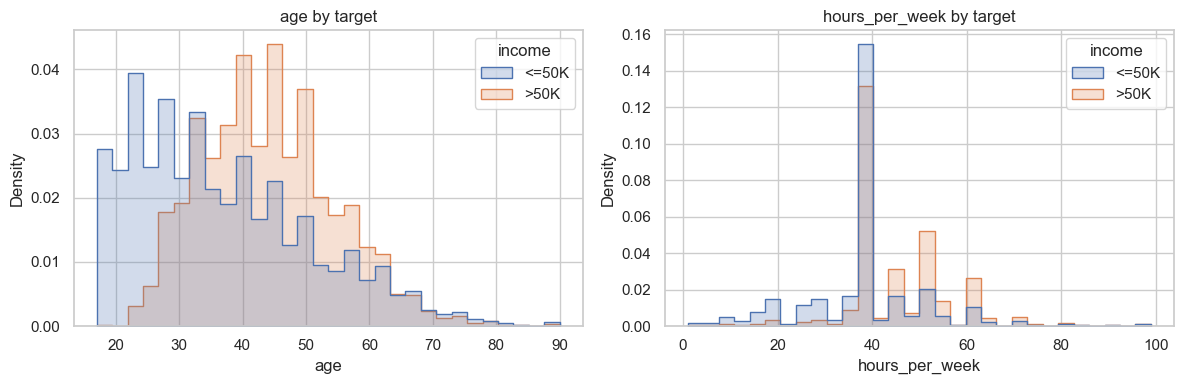

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for column, axis in zip(["age", "hours_per_week"], axes):
    sns.histplot(
        data=development,
        x=column,
        hue="income",
        bins=30,
        stat="density",
        common_norm=False,
        element="step",
        ax=axis,
    )
    axis.set_title(f"{column} by target")

plt.tight_layout()
plt.show()

In [11]:
capital_columns = ["capital_gain", "capital_loss"]
capital_summary = pd.DataFrame(index=capital_columns)
capital_summary["zero_rate_pct"] = [
    100 * development[column].eq(0).mean()
    for column in capital_columns
]
capital_summary["nonzero_rows"] = [
    development[column].gt(0).sum()
    for column in capital_columns
]
capital_summary["positive_rate_when_nonzero_pct"] = [
    100 * development.loc[development[column].gt(0), "target"].mean()
    for column in capital_columns
]
capital_summary["maximum"] = development[capital_columns].max()

display(capital_summary.round(2))
print(
    "Rows with both gain and loss above zero:",
    ((development["capital_gain"] > 0) &
     (development["capital_loss"] > 0)).sum(),
)

,zero_rate_pct,nonzero_rows,positive_rate_when_nonzero_pct,maximum
capital_gain,91.67,2170,61.24,99999
capital_loss,95.40,1198,49.50,4356


Rows with both gain and loss above zero: 0


**Decisions from the numeric audit**

- Keep age and hours as measured. No value violates the documented extraction minima, and there is no evidence for clipping.
- Zero is an observed numeric value; the question mark is the documented missing marker. Keep zero and use log1p inside the later pipeline to compress the extreme positive tail for linear and neural models.
- UCI says the source target was discretized from agrossincome but does not publish its formula. Because capital fields are same-period income-like amounts, they create a plausible target-component or timing-leakage risk for prospective use. Keep them for canonical comparability, but make the no-capital result primary for any prospective interpretation.
- fnlwgt needs a semantic decision, not generic scaling. It is handled separately below.

## 7. Redundant education fields


In [12]:
education_map = (
    development[["education_num", "education"]]
    .drop_duplicates()
    .sort_values("education_num")
    .reset_index(drop=True)
)

education_to_number = development.groupby("education")["education_num"].nunique().max()
number_to_education = development.groupby("education_num")["education"].nunique().max()

assert education_to_number == 1
assert number_to_education == 1

display(education_map)
print("The mapping is one-to-one in both directions.")

,education_num,education
0,1,Preschool
1,2,1st-4th
2,3,5th-6th
3,4,7th-8th
4,5,9th
5,6,10th
6,7,11th
7,8,12th
8,9,HS-grad
9,10,Some-college


The mapping is one-to-one in both directions.


Education and education_num contain the same information in the development partition. Keeping both would give one concept duplicate influence, especially after one-hot encoding.

**Decision:** keep the compact ordered education_num field and remove the text education field from the primary model input. This is redundancy removal, not target-based feature selection. The tradeoff is that logistic regression then assumes one smooth ordinal effect. The later benchmark should compare this choice with one-hot education as a small representation ablation.

## 8. Missingness is information, but not an explanation


In [13]:
missing_effect = []

for column in missing_columns:
    is_missing = development[column].isna()
    missing_effect.append({
        "column": column,
        "missing_rows": is_missing.sum(),
        "target_rate_missing_pct": 100 * development.loc[
            is_missing, "target"
        ].mean(),
        "target_rate_observed_pct": 100 * development.loc[
            ~is_missing, "target"
        ].mean(),
    })

pd.DataFrame(missing_effect).set_index("column").round(2)

,missing_rows,target_rate_missing_pct,target_rate_observed_pct
column,,,
workclass,1490,10.00,24.94
occupation,1496,9.96,24.94
native_country,457,24.95,24.07


Missing workclass and occupation rows have a different observed target rate. This is an association, not proof of why values are missing.

**Decision:** impute categorical missingness with an explicit Missing label inside each training fold. Do not drop rows and do not replace an unknown job with the most frequent job.

## 9. Categorical scale and rare levels


In [14]:
categorical_audit = [
    "workclass", "education", "marital_status", "occupation",
    "relationship", "race", "sex", "native_country",
]

category_summary = pd.DataFrame({
    "levels_including_missing": [
        development[column].nunique(dropna=False)
        for column in categorical_audit
    ],
    "largest_level_share_pct": [
        100 * development[column].value_counts(
            dropna=False, normalize=True
        ).max()
        for column in categorical_audit
    ],
    "levels_below_10_rows": [
        development[column].value_counts(dropna=False).lt(10).sum()
        for column in categorical_audit
    ],
}, index=categorical_audit)

display(category_summary.round(2))
display(
    development["native_country"]
    .value_counts(dropna=False)
    .sort_values()
    .head(12)
    .to_frame("rows")
)

,levels_including_missing,largest_level_share_pct,levels_below_10_rows
workclass,9,69.45,1
education,16,32.17,0
marital_status,7,46.10,0
occupation,15,12.66,1
relationship,6,40.62,0
race,5,85.42,0
sex,2,66.83,0
native_country,42,89.67,1


,rows
native_country,
Holand-Netherlands,1
Scotland,11
Honduras,12
Outlying-US(Guam-USVI-etc),13
Yugoslavia,13
Trinadad&Tobago,13
Hungary,13
Laos,14
Thailand,15


Cardinality is modest, so one-hot encoding is practical. A few training levels have fewer than 10 rows and would produce unstable standalone columns.

**Decision:** group levels below 10 observations inside each training fold and safely handle unseen categories. The threshold is deliberately small: it controls fragile single-digit categories without collapsing meaningful country detail.

## 10. Sensitive attributes: measure before judging

Race and sex are protected or sensitive attributes in many contexts. The tables below describe historical labels; they do not show causation, fairness, or model error.

In [15]:
sex_slice = development.groupby("sex", dropna=False)["target"].agg(
    rows="size",
    positive_rate="mean",
)
race_slice = development.groupby("race", dropna=False)["target"].agg(
    rows="size",
    positive_rate="mean",
)

sex_slice["positive_rate_pct"] = 100 * sex_slice.pop("positive_rate")
race_slice["positive_rate_pct"] = 100 * race_slice.pop("positive_rate")

display(sex_slice.round(2))
display(race_slice.round(2))

,rows,positive_rate_pct
sex,,
Female,8640,11.05
Male,17409,30.55


,rows,positive_rate_pct
race,,
Amer-Indian-Eskimo,257,12.06
Asian-Pac-Islander,816,24.88
Black,2503,12.39
Other,222,9.46
White,22251,25.65


The group sizes and historical target rates differ substantially. Small groups need especially cautious interpretation.

**Decision:** retain race and sex in the canonical educational benchmark and retain them for auditing. Later, report performance and error rates by group and run a no-sensitive-feature ablation. Removing these two columns alone cannot remove proxies such as relationship, occupation, or marital status.

[NIST AI RMF](https://airc.nist.gov/airmf-resources/airmf/5-sec-core/) calls for performance, fairness, bias, and limitations to be evaluated and documented. [Fairlearn's current assessment guide](https://fairlearn.org/main/user_guide/assessment/perform_fairness_assessment.html) recommends disaggregated error metrics, but metric parity alone is not proof that a system is fair.

## 11. Feature policy

| Field | Primary decision | Reason |
|---|---|---|
| age, education_num, hours_per_week | Keep numeric | Compact ordered measurements; extraction minima pass |
| capital_gain, capital_loss | Keep, then log1p | Observed zeros plus long positive tails; require a no-capital ablation |
| workclass, marital_status, occupation, relationship, race, sex, native_country | Explicit Missing plus one-hot | Low/moderate cardinality; no false ordinal order |
| education | Drop | Exactly redundant with education_num |
| fnlwgt | Exclude from primary predictors; retain separately | UCI defines it as a CPS population weight, not a personal attribute |

The [Census CPS guidance](https://www.census.gov/programs-surveys/cps/technical-documentation/methodology/producing-summary-statistics.html) explains that person weights support population-level statistics. Using fnlwgt as a model feature or sample weight changes the question being estimated. With no deployment population specified, the primary benchmark excludes it and preserves it for an explicit sensitivity analysis.

In [16]:
regular_numeric = ["age", "education_num", "hours_per_week"]
capital_numeric = ["capital_gain", "capital_loss"]
categorical_features = [
    "workclass", "marital_status", "occupation", "relationship",
    "race", "sex", "native_country",
]
model_features = regular_numeric + capital_numeric + categorical_features

X_development = development[model_features].copy()
y_development = development["target"].copy()
survey_weight_development = development["fnlwgt"].copy()

X_locked_test = locked_test[model_features].copy()
y_locked_test = locked_test["target"].copy()
survey_weight_locked_test = locked_test["fnlwgt"].copy()

assert X_development.columns.tolist() == model_features
assert X_locked_test.columns.tolist() == model_features
assert y_development.isin([0, 1]).all()

pd.Series({
    "development rows": len(X_development),
    "locked test rows": len(X_locked_test),
    "primary model features": X_development.shape[1],
    "numeric features": len(regular_numeric) + len(capital_numeric),
    "categorical features": len(categorical_features),
}).to_frame("value")

,value
development rows,26049
locked test rows,6512
primary model features,12
numeric features,5
categorical features,7


## 12. Leakage-safe preprocessing object

All learned operations live inside one ColumnTransformer:

- median fallback and scaling for regular numeric fields;
- median fallback, log1p, and scaling for zero-heavy capital fields;
- explicit Missing, rare-level grouping, and one-hot encoding for categories.

Scaling matters for regularized linear and neural models. Log1p is monotonic, so it does not remove the ordering used by tree models. Dense output is acceptable here because cardinality and measured memory are small; it also gives one shared input format for the later compact model stack.

[Scikit-learn's pipeline documentation](https://scikit-learn.org/stable/modules/compose.html) explains why a transformer must be fitted inside each CV fold. [OneHotEncoder](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html) provides explicit handling for infrequent and unseen levels.

In [17]:
regular_numeric_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
])

capital_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("log1p", FunctionTransformer(
        np.log1p,
        feature_names_out="one-to-one",
    )),
    ("scale", StandardScaler()),
])

categorical_pipeline = Pipeline([
    ("impute", SimpleImputer(
        strategy="constant",
        fill_value="Missing",
    )),
    ("onehot", OneHotEncoder(
        handle_unknown="infrequent_if_exist",
        min_frequency=10,
        sparse_output=False,
        dtype=np.float32,
    )),
])

preprocessor = ColumnTransformer([
    ("numeric", regular_numeric_pipeline, regular_numeric),
    ("capital", capital_pipeline, capital_numeric),
    ("categorical", categorical_pipeline, categorical_features),
], verbose_feature_names_out=False)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('capital', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_n

### Smoke-test one development fold

This is a schema and memory test, not model training. The transformer is cloned, fitted on one development fold, and applied to its validation fold. The locked test is not transformed or fitted.

In [18]:
benchmark_cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)
fold_train_position, fold_valid_position = next(
    benchmark_cv.split(
        X_development,
        y_development,
        development_group,
    )
)

preview_preprocessor = clone(preprocessor)
fold_train_ready = preview_preprocessor.fit_transform(
    X_development.iloc[fold_train_position]
)
fold_valid_ready = preview_preprocessor.transform(
    X_development.iloc[fold_valid_position]
)
transformed_names = preview_preprocessor.get_feature_names_out()

assert fold_train_ready.shape[1] == fold_valid_ready.shape[1]
assert np.isfinite(fold_train_ready).all()
assert np.isfinite(fold_valid_ready).all()

pd.Series({
    "fold train rows": fold_train_ready.shape[0],
    "fold validation rows": fold_valid_ready.shape[0],
    "transformed features": fold_train_ready.shape[1],
    "train matrix MiB": fold_train_ready.nbytes / 1024**2,
    "finite train values": np.isfinite(fold_train_ready).all(),
    "finite validation values": np.isfinite(fold_valid_ready).all(),
}).to_frame("smoke_test")

,smoke_test
fold train rows,20839
fold validation rows,5210
transformed features,89
train matrix MiB,14.150017
finite train values,True
finite validation values,True


In [19]:
pd.Series(transformed_names, name="transformed_feature").head(20).to_frame()

,transformed_feature
0,age
1,education_num
2,hours_per_week
3,capital_gain
4,capital_loss
5,workclass_Federal-gov
6,workclass_Local-gov
7,workclass_Missing
8,workclass_Private
9,workclass_Self-emp-inc


> **Senior habit:** do not save one globally preprocessed table for cross-validation. Put this unfitted preprocessor inside every model Pipeline so imputation, scaling, and category learning happen again inside each fold.

## 13. Benchmark hand-off

The next notebook should use this exact contract:

1. **Same data:** X_development, y_development, development_group, and one locked test.
2. **Same folds:** five shuffled StratifiedGroupKFold splits for every model.
3. **Same pipeline rule:** clone the unfitted preprocessor inside every model Pipeline.
4. **Compact stack:** DummyClassifier, logistic regression, one bagged-tree model, one boosted-tree model, and a small MLP neural baseline with early stopping.
5. **Primary comparison metric:** balanced accuracy, predeclared here because it gives equal importance to recall in both classes. This is an educational convention, not business utility. Also report ROC AUC, average precision, precision, recall, F1, accuracy, fit time, and score time.
6. **Threshold rule:** select any non-0.5 threshold only from out-of-fold development predictions and a stated error cost; never tune it on the test set.
7. **Final report:** evaluate the selected configuration once on the locked test, then report confusion matrix, calibration if probabilities matter, and error slices by sex and race with sample counts.
8. **Ablations:** no sensitive fields; no capital fields; one-hot versus ordinal education; fnlwgt as a conventional predictor; and, separately, population-weighted evaluation. Never conflate the last two because they answer different questions.

[Scikit-learn's metrics guide](https://scikit-learn.org/stable/modules/model_evaluation.html) defines balanced accuracy as an answer to inflated performance under imbalance. Its [threshold guide](https://scikit-learn.org/stable/modules/classification_threshold.html) separates probability estimation from the decision rule. A broad [tabular benchmark at NeurIPS 2022](https://papers.nips.cc/paper_files/paper/2022/hash/0378c7692da36807bdec87ab043cdadc-Abstract-Datasets_and_Benchmarks.html) found tree ensembles remained strong on medium-sized tabular data, so the MLP is a comparison—not an assumed upgrade.

In [20]:
benchmark_contract = pd.Series({
    "random_state": RANDOM_STATE,
    "development_rows": len(X_development),
    "locked_test_rows": len(X_locked_test),
    "development_positive_rate": y_development.mean(),
    "majority_accuracy_baseline": majority_accuracy,
    "cv_folds": benchmark_cv.n_splits,
    "raw_14_feature_profile_overlap": 0,
    "primary_metric": "balanced_accuracy",
    "test_evaluations_allowed": 1,
})
benchmark_contract.to_frame("value")

,value
random_state,42
development_rows,26049
locked_test_rows,6512
development_positive_rate,0.240815
majority_accuracy_baseline,0.759185
cv_folds,5
raw_14_feature_profile_overlap,0
primary_metric,balanced_accuracy
test_evaluations_allowed,1


## 14. Portfolio and real-work value

There is no universal 2026 recruiter checklist. A conservative evidence-based proxy is the work described by official occupational sources:

- The [U.S. Bureau of Labor Statistics Data Scientists profile](https://www.bls.gov/ooh/math/data-scientists.htm), last modified in 2025, includes finding useful data, cleaning it, creating/validating/testing models, visualization, business recommendations, and communication.
- The [O*NET Data Warehousing Specialists profile](https://www.onetonline.org/link/summary/15-1243.01), updated in 2026, includes sourcing/loading/transformation, verifying structure and quality, standards, testing, and documentation.

This notebook demonstrates those fundamentals with provenance, a pinned schema, quality checks, measured decisions, leakage control, reproducible splits, a reusable pipeline, resource awareness, and clear limitations. For this notebook's limited scope, these artifacts directly demonstrate the cited duties. Deployment infrastructure would be relevant only if deployment were part of the stated project.

## 15. Honest conclusion

- The local data are parseable and structurally consistent, but missingness, duplicate profiles, target imbalance, redundant education fields, rare categories, and sensitive attributes require explicit handling.
- No rows were dropped. Missing categories are preserved, repeated full profiles cannot cross evaluation boundaries, and all learned preprocessing is fold-local.
- The primary feature policy is practical but not universal. fnlwgt, protected fields, and contemporaneous capital fields need deployment-specific review and ablation.
- This is a historical 1994 educational benchmark. A $50K label from that period is not a current-income standard, and this notebook does not justify use in hiring, lending, benefits, or other high-impact decisions.
- The locked holdout estimates same-source random-row generalization while keeping identical 14-feature profiles together. It is not the official UCI test set and cannot establish temporal or modern-population generalization.

**Selected sources reviewed:** [UCI dataset card](https://doi.org/10.24432/C5XW20), [UCI adult.names](https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.names), [Census CPS weighting guidance](https://www.census.gov/programs-surveys/cps/technical-documentation/methodology/producing-summary-statistics.html), [scikit-learn common pitfalls](https://scikit-learn.org/stable/common_pitfalls.html), [scikit-learn pipelines](https://scikit-learn.org/stable/modules/compose.html), [scikit-learn evaluation](https://scikit-learn.org/stable/modules/model_evaluation.html), [NIST AI RMF](https://airc.nist.gov/airmf-resources/airmf/5-sec-core/), [Fairlearn assessment guidance](https://fairlearn.org/main/user_guide/assessment/perform_fairness_assessment.html), [BLS Data Scientists](https://www.bls.gov/ooh/math/data-scientists.htm), and [O*NET Data Warehousing Specialists](https://www.onetonline.org/link/summary/15-1243.01). This notebook executed with scikit-learn 1.8.0; methodological guidance was checked against scikit-learn 1.9.0 and Fairlearn 0.14 on 2026-07-18.